# Section 1 Question 1

Quantifying the impact of the HDB Resale Portal on property agents.

In [ ]:
# Section 1 Q1 - HDB Resale Portal impact on property agents
# Zhang Jie
#
# Data used:
# - HDB Resale Flat Prices from Jan 2017 onwards
# - CEA Salespersons' Property Transaction Records (Residential)
#
# The CEA data has no unique transaction ID - each row is a salesperson
# representation record, so a resale with a buyer's and seller's agent both
# shows up twice. I'm counting these as "agent representation records" rather
# than transactions, which is good enough for tracking how much agent
# business activity there is even if it isn't an exact transaction count.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")  # change this if needed
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HDB_FILE = DATA_DIR / "Resale flat prices based on registration date from Jan-2017 onwards.csv"
CEA_FILE = DATA_DIR / "CEASalespersonsPropertyTransactionRecordsresidential.csv"



In [2]:
# Load data
hdb = pd.read_csv(HDB_FILE)
cea = pd.read_csv(CEA_FILE)

print("HDB rows:", hdb.shape)
print("CEA rows:", cea.shape)
print("\nHDB columns:", hdb.columns.tolist())
print("\nCEA columns:", cea.columns.tolist())

# Parse dates
hdb["date"] = pd.to_datetime(hdb["month"] + "-01")
cea["date"] = pd.to_datetime(cea["transaction_date"], format="%b-%Y", errors="coerce")

# Basic checks
print("\nHDB date range:", hdb["date"].min().date(), "to", hdb["date"].max().date())
print("CEA date range:", cea["date"].min().date(), "to", cea["date"].max().date())
print("CEA date parse failures:", cea["date"].isna().sum())

# Keep only common date window to avoid artificial drop caused by one dataset being more updated than the other
common_end = min(hdb["date"].max(), cea["date"].max())
hdb = hdb[hdb["date"] <= common_end].copy()
cea = cea[cea["date"] <= common_end].copy()
print("Common analysis end month:", common_end.strftime("%Y-%m"))

HDB rows: (234672, 11)
CEA rows: (1341539, 9)

HDB columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']

CEA columns: ['salesperson_name', 'transaction_date', 'salesperson_reg_num', 'property_type', 'transaction_type', 'represented', 'town', 'district', 'general_location']

HDB date range: 2017-01-01 to 2026-07-01
CEA date range: 2017-01-01 to 2026-06-01
CEA date parse failures: 0


Common analysis end month: 2026-06


In [3]:
# Filter CEA to HDB resale representation records
cea_hdb_resale = cea[
    (cea["property_type"].str.upper() == "HDB") &
    (cea["transaction_type"].str.upper() == "RESALE")
].copy()

print("CEA HDB resale representation records:", cea_hdb_resale.shape[0])
display(cea_hdb_resale["represented"].value_counts().to_frame("records"))

# Monthly HDB resale transaction volume
hdb_monthly = (
    hdb.groupby("date")
       .size()
       .rename("hdb_resale_transactions")
       .reset_index()
)

# Monthly CEA HDB resale representation records
cea_monthly_side = (
    cea_hdb_resale.groupby(["date", "represented"])
                  .size()
                  .unstack(fill_value=0)
                  .reset_index()
)

# Ensure expected columns exist
for col in ["SELLER", "BUYER"]:
    if col not in cea_monthly_side.columns:
        cea_monthly_side[col] = 0

cea_monthly_side["agent_engagements"] = cea_monthly_side[["SELLER", "BUYER"]].sum(axis=1)

monthly = (
    hdb_monthly.merge(cea_monthly_side, on="date", how="left")
               .fillna({"SELLER": 0, "BUYER": 0, "agent_engagements": 0})
)

monthly["year"] = monthly["date"].dt.year
monthly["month_num"] = monthly["date"].dt.month

# Main metrics
monthly["agent_engagements_per_100_resales"] = monthly["agent_engagements"] / monthly["hdb_resale_transactions"] * 100
monthly["seller_rep_records_per_100_resales"] = monthly["SELLER"] / monthly["hdb_resale_transactions"] * 100
monthly["buyer_rep_records_per_100_resales"] = monthly["BUYER"] / monthly["hdb_resale_transactions"] * 100

display(monthly.head())

CEA HDB resale representation records: 351812


,records
represented,
SELLER,213818
BUYER,137994


,date,hdb_resale_transactions,BUYER,SELLER,agent_engagements,year,month_num,agent_engagements_per_100_resales,seller_rep_records_per_100_resales,buyer_rep_records_per_100_resales
0,2017-01-01,1185,1053,1400,2453,2017,1,207.004219,118.143460,88.860759
1,2017-02-01,1085,1086,1510,2596,2017,2,239.262673,139.170507,100.092166
2,2017-03-01,1903,935,1375,2310,2017,3,121.387283,72.254335,49.132948
3,2017-04-01,1839,1003,1465,2468,2017,4,134.203371,79.662860,54.540511
4,2017-05-01,1980,1096,1617,2713,2017,5,137.020202,81.666667,55.353535


In [4]:
# Annual view.
# For clean year-on-year story, use full calendar years 2017-2025 if 2026 is partial.
yearly = (
    monthly.groupby("year")
           .agg(
               hdb_resale_transactions=("hdb_resale_transactions", "sum"),
               agent_engagements=("agent_engagements", "sum"),
               seller_rep_records=("SELLER", "sum"),
               buyer_rep_records=("BUYER", "sum"),
               months_observed=("date", "nunique")
           )
           .reset_index()
)

yearly["agent_engagements_per_100_resales"] = yearly["agent_engagements"] / yearly["hdb_resale_transactions"] * 100
yearly["seller_rep_records_per_100_resales"] = yearly["seller_rep_records"] / yearly["hdb_resale_transactions"] * 100
yearly["buyer_rep_records_per_100_resales"] = yearly["buyer_rep_records"] / yearly["hdb_resale_transactions"] * 100

full_yearly = yearly[yearly["months_observed"] == 12].copy()

display(yearly.round(1))
display(full_yearly.round(1))

# Pre/post comparison:
# 2017 = pre-portal baseline
# 2018 = launch/transition year
# 2019-2025 = post-launch mature period
pre_2017 = full_yearly[full_yearly["year"] == 2017].iloc[0]
post_mature = full_yearly[(full_yearly["year"] >= 2019) & (full_yearly["year"] <= 2025)]

impact_summary = pd.DataFrame({
    "metric": [
        "HDB resale transactions per year",
        "Agent representation records per year",
        "Agent representation records per 100 resales",
        "Seller-side representation records per 100 resales",
        "Buyer-side representation records per 100 resales"
    ],
    "2017_baseline": [
        pre_2017["hdb_resale_transactions"],
        pre_2017["agent_engagements"],
        pre_2017["agent_engagements_per_100_resales"],
        pre_2017["seller_rep_records_per_100_resales"],
        pre_2017["buyer_rep_records_per_100_resales"]
    ],
    "2019_2025_average": [
        post_mature["hdb_resale_transactions"].mean(),
        post_mature["agent_engagements"].mean(),
        post_mature["agent_engagements_per_100_resales"].mean(),
        post_mature["seller_rep_records_per_100_resales"].mean(),
        post_mature["buyer_rep_records_per_100_resales"].mean()
    ]
})

impact_summary["absolute_change"] = impact_summary["2019_2025_average"] - impact_summary["2017_baseline"]
impact_summary["pct_change_vs_2017"] = impact_summary["absolute_change"] / impact_summary["2017_baseline"] * 100

display(impact_summary.round(2))
impact_summary.to_csv(OUTPUT_DIR / "impact_summary.csv", index=False)
yearly.to_csv(OUTPUT_DIR / "yearly_metrics.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "monthly_metrics.csv", index=False)

,year,hdb_resale_transactions,agent_engagements,seller_rep_records,buyer_rep_records,months_observed,agent_engagements_per_100_resales,seller_rep_records_per_100_resales,buyer_rep_records_per_100_resales
0,2017,20509,31162,18670,12492,12,151.9,91.0,60.9
1,2018,21561,35674,22405,13269,12,165.5,103.9,61.5
2,2019,22186,30461,19407,11054,12,137.3,87.5,49.8
3,2020,23333,32524,20421,12103,12,139.4,87.5,51.9
4,2021,29087,43978,26976,17002,12,151.2,92.7,58.5
5,2022,26720,41606,25122,16484,12,155.7,94.0,61.7
6,2023,25754,39191,23326,15865,12,152.2,90.6,61.6
7,2024,27832,42646,25037,17609,12,153.2,90.0,63.3
8,2025,25085,39733,23489,16244,12,158.4,93.6,64.8
9,2026,12245,14837,8965,5872,6,121.2,73.2,48.0


,year,hdb_resale_transactions,agent_engagements,seller_rep_records,buyer_rep_records,months_observed,agent_engagements_per_100_resales,seller_rep_records_per_100_resales,buyer_rep_records_per_100_resales
0,2017,20509,31162,18670,12492,12,151.9,91.0,60.9
1,2018,21561,35674,22405,13269,12,165.5,103.9,61.5
2,2019,22186,30461,19407,11054,12,137.3,87.5,49.8
3,2020,23333,32524,20421,12103,12,139.4,87.5,51.9
4,2021,29087,43978,26976,17002,12,151.2,92.7,58.5
5,2022,26720,41606,25122,16484,12,155.7,94.0,61.7
6,2023,25754,39191,23326,15865,12,152.2,90.6,61.6
7,2024,27832,42646,25037,17609,12,153.2,90.0,63.3
8,2025,25085,39733,23489,16244,12,158.4,93.6,64.8


,metric,2017_baseline,2019_2025_average,absolute_change,pct_change_vs_2017
0,HDB resale transactions per year,20509.00,25713.86,5204.86,25.38
1,Agent representation records per year,31162.00,38591.29,7429.29,23.84
2,Agent representation records per 100 resales,151.94,149.63,-2.32,-1.52
3,Seller-side representation records per 100 res...,91.03,90.85,-0.19,-0.21
4,Buyer-side representation records per 100 resales,60.91,58.78,-2.13,-3.50


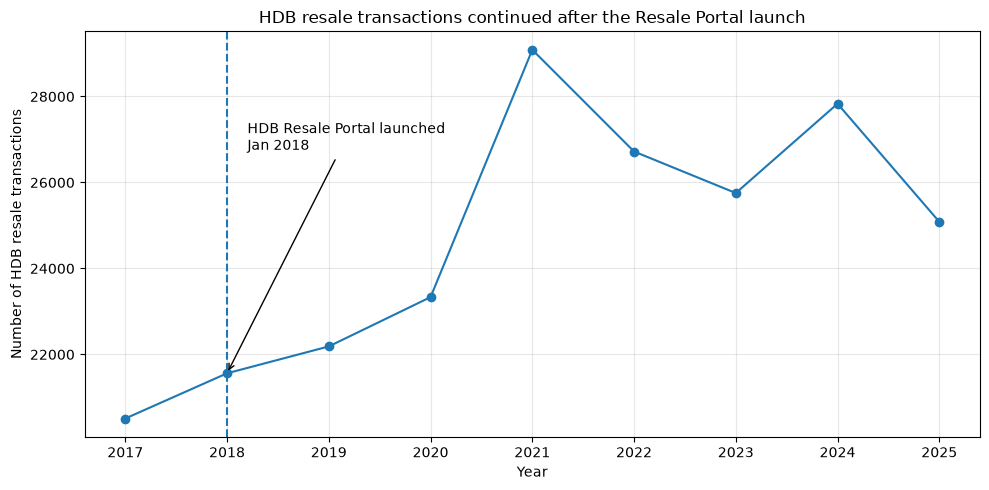

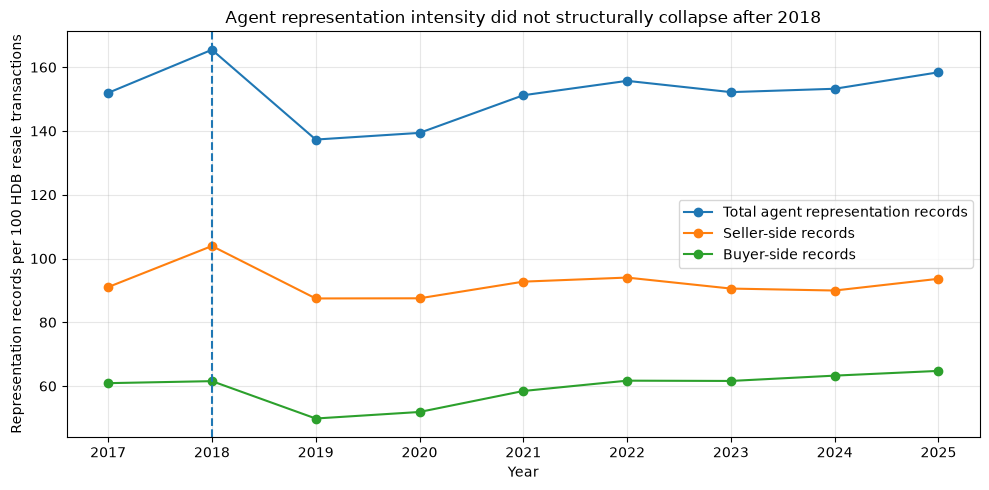

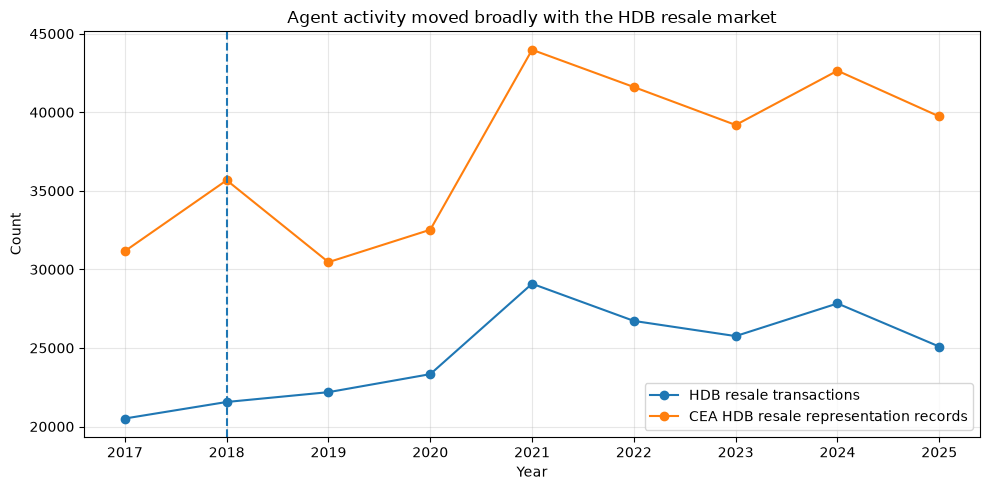

In [5]:
# Chart 1: HDB resale market grew after portal launch
plt.figure(figsize=(10, 5))
plt.plot(full_yearly["year"], full_yearly["hdb_resale_transactions"], marker="o")
plt.axvline(2018, linestyle="--")
plt.title("HDB resale transactions continued after the Resale Portal launch")
plt.xlabel("Year")
plt.ylabel("Number of HDB resale transactions")
plt.grid(True, alpha=0.3)
plt.annotate("HDB Resale Portal launched\nJan 2018", xy=(2018, full_yearly.loc[full_yearly["year"]==2018, "hdb_resale_transactions"].values[0]),
             xytext=(2018.2, full_yearly["hdb_resale_transactions"].max()*0.92),
             arrowprops=dict(arrowstyle="->"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_1_hdb_resale_volume.png", dpi=200)
plt.show()

# Chart 2: Agent engagement intensity
plt.figure(figsize=(10, 5))
plt.plot(full_yearly["year"], full_yearly["agent_engagements_per_100_resales"], marker="o", label="Total agent representation records")
plt.plot(full_yearly["year"], full_yearly["seller_rep_records_per_100_resales"], marker="o", label="Seller-side records")
plt.plot(full_yearly["year"], full_yearly["buyer_rep_records_per_100_resales"], marker="o", label="Buyer-side records")
plt.axvline(2018, linestyle="--")
plt.title("Agent representation intensity did not structurally collapse after 2018")
plt.xlabel("Year")
plt.ylabel("Representation records per 100 HDB resale transactions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_2_agent_intensity.png", dpi=200)
plt.show()

# Chart 3: Market volume vs agent records
plt.figure(figsize=(10, 5))
plt.plot(full_yearly["year"], full_yearly["hdb_resale_transactions"], marker="o", label="HDB resale transactions")
plt.plot(full_yearly["year"], full_yearly["agent_engagements"], marker="o", label="CEA HDB resale representation records")
plt.axvline(2018, linestyle="--")
plt.title("Agent activity moved broadly with the HDB resale market")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_3_market_vs_agent_records.png", dpi=200)
plt.show()

year,town_clean,2017,2025,change_per_100_resales
6,BUKIT TIMAH,150.9,122.2,-28.7
9,CLEMENTI,158.9,145.5,-13.4
7,CENTRAL AREA,147.8,134.9,-12.9
1,BEDOK,161.5,154.8,-6.7
11,HOUGANG,159.3,153.2,-6.1
0,ANG MO KIO,157.2,153.1,-4.1
21,SERANGOON,150.7,146.8,-3.9
2,BISHAN,141.7,138.3,-3.4
20,SENGKANG,162.3,160.7,-1.6
4,BUKIT MERAH,138.2,137.8,-0.4


year,town_clean,2017,2025,change_per_100_resales
24,WOODLANDS,159.6,170.4,10.8
8,CHOA CHU KANG,157.7,168.6,10.9
14,KALLANG/WHAMPOA,131.1,142.8,11.7
16,PASIR RIS,148.7,163.6,14.8
13,JURONG WEST,151.7,167.1,15.3
10,GEYLANG,127.9,147.1,19.2
15,MARINE PARADE,117.7,137.7,19.9
12,JURONG EAST,142.7,163.3,20.6
18,QUEENSTOWN,133.0,154.9,21.9
17,PUNGGOL,144.9,167.9,23.0


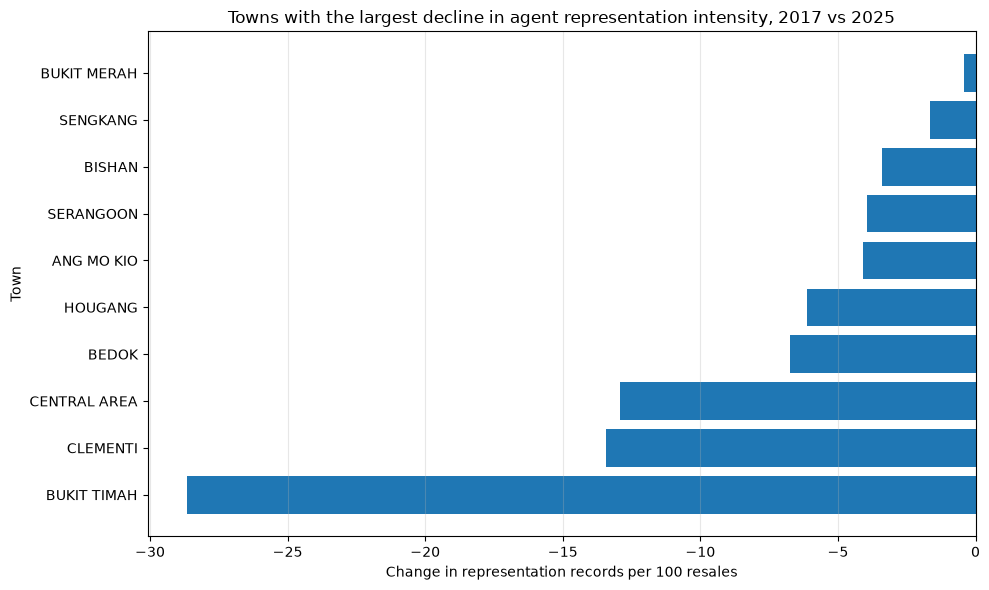

In [6]:
# Town-level story: where did representation intensity change most?
hdb["town_clean"] = hdb["town"].str.upper().str.strip()
cea_hdb_resale["town_clean"] = cea_hdb_resale["town"].str.upper().str.strip()

hdb_town_year = (
    hdb.groupby([hdb["date"].dt.year.rename("year"), "town_clean"])
       .size()
       .rename("hdb_resale_transactions")
       .reset_index()
)

cea_town_year = (
    cea_hdb_resale.groupby([cea_hdb_resale["date"].dt.year.rename("year"), "town_clean"])
                  .size()
                  .rename("agent_engagements")
                  .reset_index()
)

town_year = (
    hdb_town_year.merge(cea_town_year, on=["year", "town_clean"], how="left")
                 .fillna({"agent_engagements": 0})
)
town_year["agent_engagements_per_100_resales"] = town_year["agent_engagements"] / town_year["hdb_resale_transactions"] * 100

# Compare 2017 vs latest complete year
latest_full_year = int(full_yearly["year"].max())
town_change = (
    town_year[town_year["year"].isin([2017, latest_full_year])]
    .pivot(index="town_clean", columns="year", values="agent_engagements_per_100_resales")
    .dropna()
    .reset_index()
)
town_change["change_per_100_resales"] = town_change[latest_full_year] - town_change[2017]
town_change = town_change.sort_values("change_per_100_resales")

display(town_change.head(10).round(1))
display(town_change.tail(10).round(1))

town_change.to_csv(OUTPUT_DIR / "town_change_2017_vs_latest_full_year.csv", index=False)

# Chart 4: Top declines
top_declines = town_change.head(10).sort_values("change_per_100_resales")
plt.figure(figsize=(10, 6))
plt.barh(top_declines["town_clean"], top_declines["change_per_100_resales"])
plt.title(f"Towns with the largest decline in agent representation intensity, 2017 vs {latest_full_year}")
plt.xlabel("Change in representation records per 100 resales")
plt.ylabel("Town")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_4_top_town_declines.png", dpi=200)
plt.show()